In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('train.csv')
display(df.head(5))

,neighbourhood_group,room_type,minimum_nights,amenity_score,number_of_reviews,availability_365,price_class
0,Manhattan,NaN,2.0,82.5,15.0,254.0,3
1,Manhattan,Private room,2.0,53.7,1.0,0.0,1
2,Brooklyn,Private room,2.0,47.8,70.0,90.0,1
3,Manhattan,Entire home/apt,2.0,58.8,1.0,NaN,1
4,Bronx,Private room,2.0,32.2,0.0,89.0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41348 entries, 0 to 41347
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  40509 non-null  str    
 1   room_type            40737 non-null  str    
 2   minimum_nights       40026 non-null  float64
 3   amenity_score        40432 non-null  float64
 4   number_of_reviews    40225 non-null  float64
 5   availability_365     40753 non-null  float64
 6   price_class          41348 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 2.2 MB


In [4]:
df.dropna(subset=['neighbourhood_group', 'room_type'], inplace=True)

df['minimum_nights'] = df['minimum_nights'].fillna(df['minimum_nights'].median())
df['availability_365'] = df['availability_365'].fillna(df['availability_365'].median())

df['amenity_score'] = df['amenity_score'].fillna(df['amenity_score'].mean())

df['number_of_reviews'] = df['number_of_reviews'].fillna(0)

df.info()

<class 'pandas.DataFrame'>
Index: 39905 entries, 1 to 41347
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  39905 non-null  str    
 1   room_type            39905 non-null  str    
 2   minimum_nights       39905 non-null  float64
 3   amenity_score        39905 non-null  float64
 4   number_of_reviews    39905 non-null  float64
 5   availability_365     39905 non-null  float64
 6   price_class          39905 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 2.4 MB


Class Distribution:
price_class
1    22477
2     9502
0     5372
3     2554
Name: count, dtype: int64

Percentage Distribution:
price_class
1    56.326275
2    23.811552
0    13.461972
3     6.400200
Name: proportion, dtype: float64


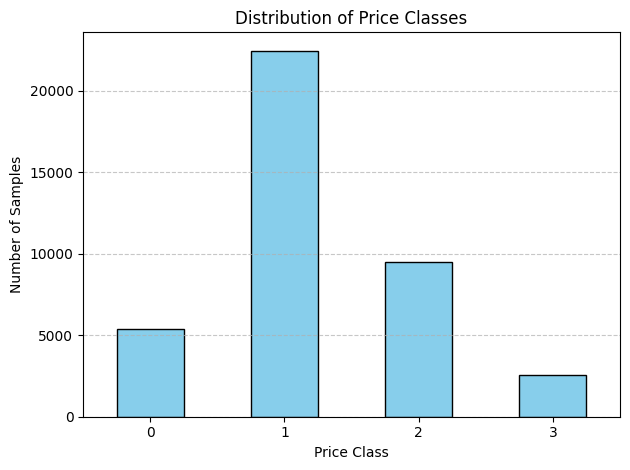

In [5]:
class_counts = df['price_class'].value_counts()
class_percentages = df['price_class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(class_counts)
print("\nPercentage Distribution:")
print(class_percentages)

class_counts.sort_index().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of Price Classes')
plt.xlabel('Price Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('report/figs/class_dist.png')

In [6]:
X = df.drop('price_class', axis=1)
y = df['price_class']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
categoricals = ['neighbourhood_group', 'room_type']
numericals = ['minimum_nights', 'amenity_score', 'number_of_reviews', 'availability_365']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categoricals),
        ('num', StandardScaler(), numericals)
    ]
)

preprocessor.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [8]:
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)

display(X_train.head())

,cat__neighbourhood_group_Brooklyn,cat__neighbourhood_group_Manhattan,cat__neighbourhood_group_Queens,cat__neighbourhood_group_Staten Island,cat__room_type_Private room,cat__room_type_Shared room,num__minimum_nights,num__amenity_score,num__number_of_reviews,num__availability_365
27639,0.0,1.0,0.0,0.0,1.0,0.0,-0.293163,-0.034620,0.312637,0.219625
29027,1.0,0.0,0.0,0.0,0.0,0.0,-0.243120,0.459170,-0.386223,-0.801273
1457,0.0,1.0,0.0,0.0,0.0,0.0,1.158093,0.968554,-0.521486,-0.847329
15666,1.0,0.0,0.0,0.0,1.0,0.0,-0.293163,-0.481631,-0.205872,0.334764
14626,1.0,0.0,0.0,0.0,0.0,0.0,1.158093,1.077707,-0.521486,0.657153


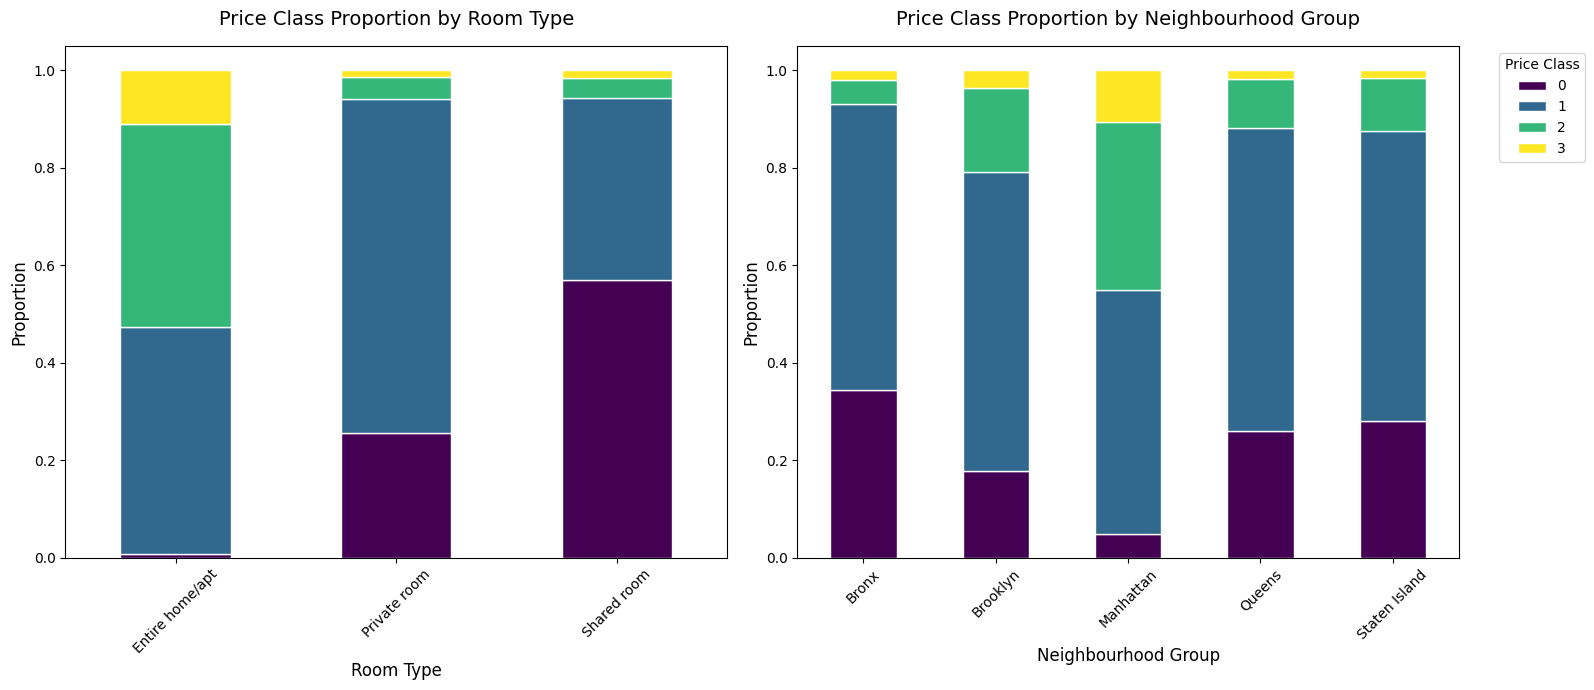

In [9]:
cat_features = ['room_type', 'neighbourhood_group']
target = 'price_class'
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, feature in enumerate(cat_features):
    ct = pd.crosstab(df[feature], df[target], normalize='index')

    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', edgecolor='white')
    
    axes[i].set_title(f'Price Class Proportion by {feature.replace("_", " ").title()}', fontsize=14, pad=15)
    axes[i].set_ylabel('Proportion', fontsize=12)
    axes[i].set_xlabel(feature.replace("_", " ").title(), fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    
    if i == 1:
        axes[i].legend(title='Price Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.savefig('report/figs/cat_comb_dist.png', dpi=300)
plt.show()

/tmp/ipykernel_67984/3720655613.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_class', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_67984/3720655613.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_class', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_67984/3720655613.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_class', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_67984/3720655613.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is dep

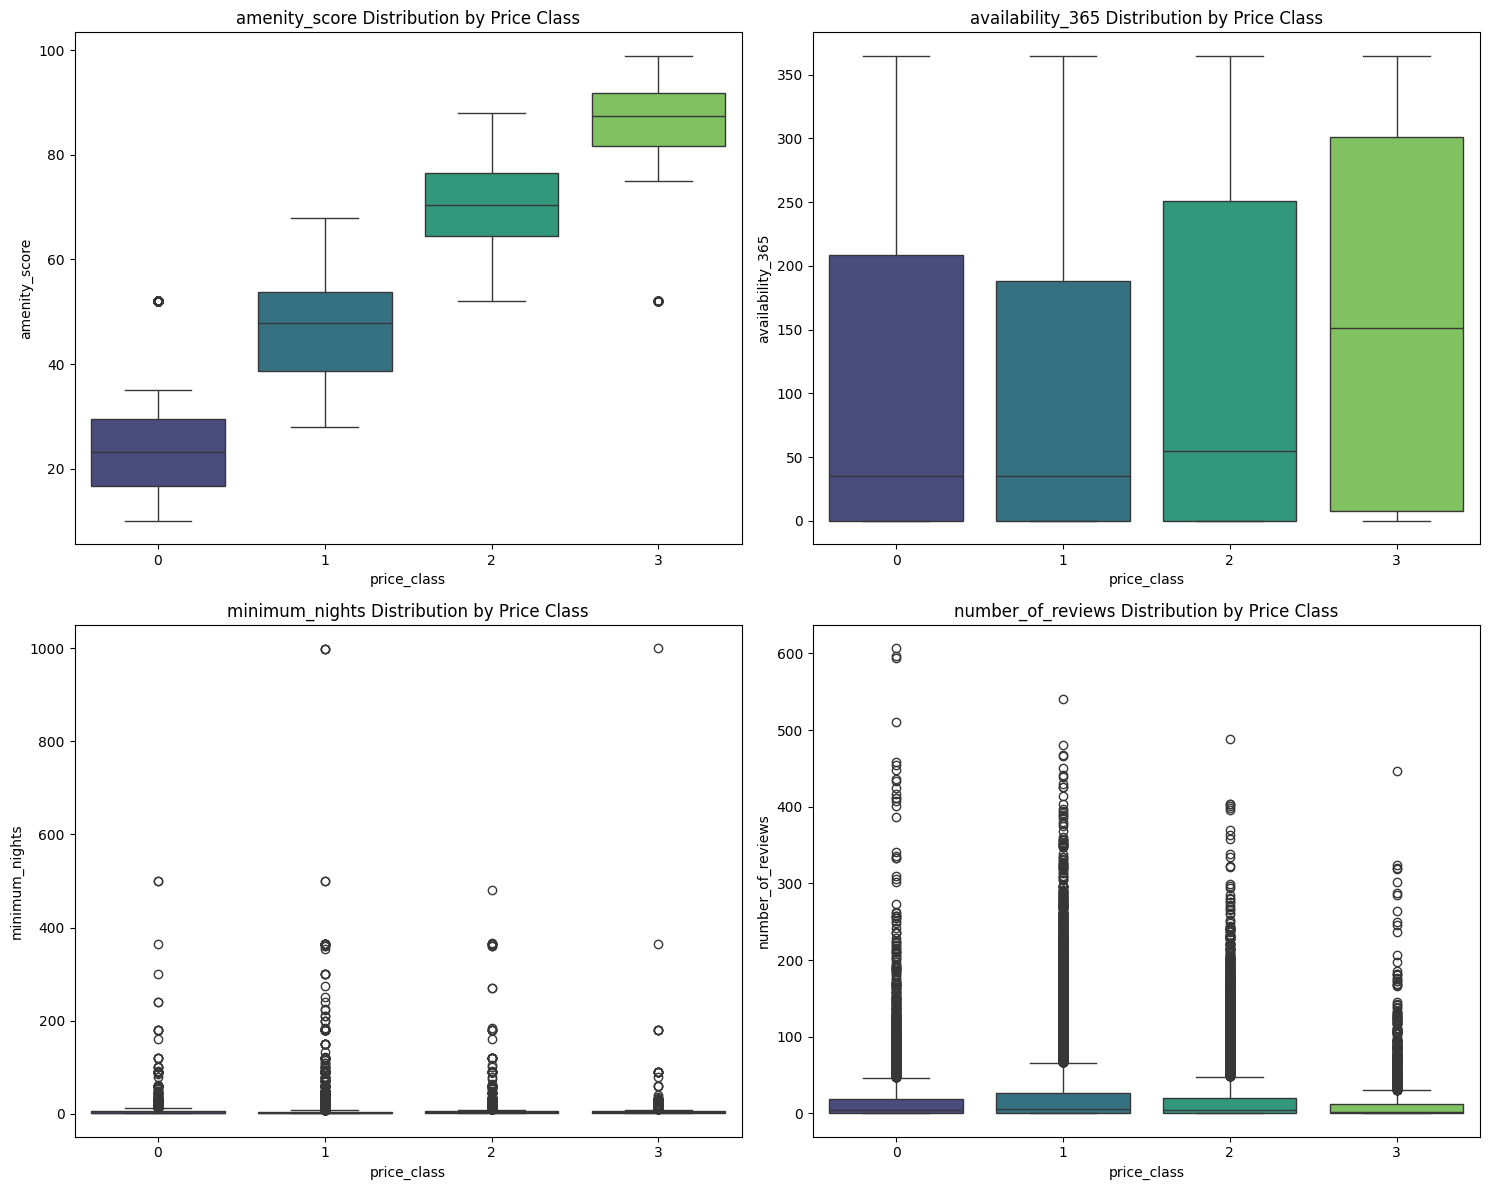

In [10]:
num_features = ['amenity_score', 'availability_365', 'minimum_nights', 'number_of_reviews']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(x='price_class', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} Distribution by Price Class')

plt.tight_layout()
plt.savefig('report/figs/num_comb_dist.png', dpi=300)
plt.show()

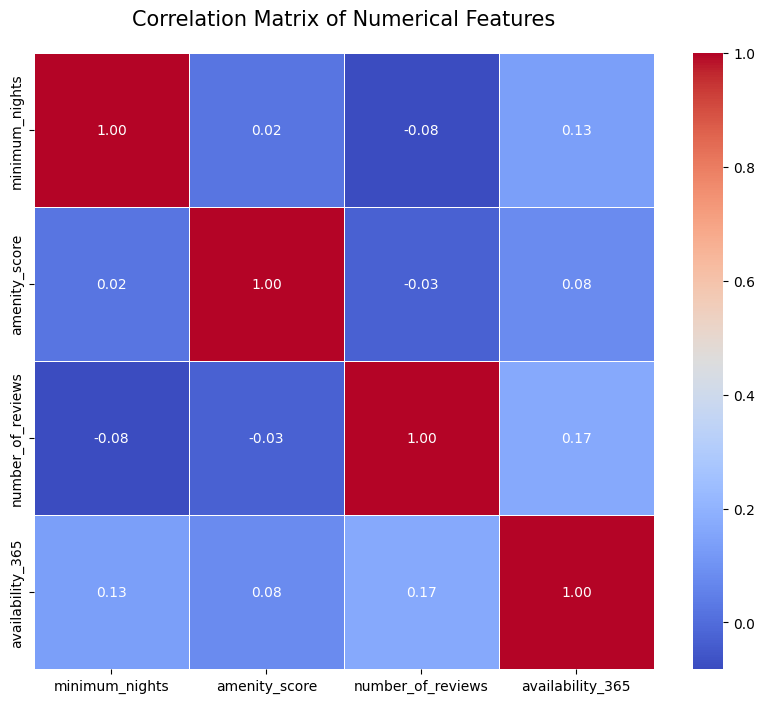

In [11]:
corr_matrix = df[['minimum_nights', 'amenity_score', 'number_of_reviews', 'availability_365']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Numerical Features', fontsize=15, pad=20)
plt.savefig('report/figs/corr_map.png', dpi=300)
plt.show()

In [12]:
display(X_train)
display(y_train)

,cat__neighbourhood_group_Brooklyn,cat__neighbourhood_group_Manhattan,cat__neighbourhood_group_Queens,cat__neighbourhood_group_Staten Island,cat__room_type_Private room,cat__room_type_Shared room,num__minimum_nights,num__amenity_score,num__number_of_reviews,num__availability_365
27639,0.0,1.0,0.0,0.0,1.0,0.0,-0.293163,-0.034620,0.312637,0.219625
29027,1.0,0.0,0.0,0.0,0.0,0.0,-0.243120,0.459170,-0.386223,-0.801273
1457,0.0,1.0,0.0,0.0,0.0,0.0,1.158093,0.968554,-0.521486,-0.847329
15666,1.0,0.0,0.0,0.0,1.0,0.0,-0.293163,-0.481631,-0.205872,0.334764
14626,1.0,0.0,0.0,0.0,0.0,0.0,1.158093,1.077707,-0.521486,0.657153
...,...,...,...,...,...,...,...,...,...,...
6791,1.0,0.0,0.0,0.0,1.0,0.0,-0.243120,0.001764,0.786057,-0.847329
22332,0.0,1.0,0.0,0.0,1.0,0.0,-0.092990,-0.663553,-0.115696,0.334764
11665,1.0,0.0,0.0,0.0,0.0,0.0,-0.243120,0.583917,-0.498942,-0.808949
12839,0.0,1.0,0.0,0.0,0.0,0.0,-0.243120,0.479961,-0.408766,-0.847329


27639    1
29027    1
1457     2
15666    1
14626    2
        ..
6791     1
22332    1
11665    2
12839    2
5547     1
Name: price_class, Length: 31924, dtype: int64

In [13]:
class FFNN:
    def __init__(self, input_size, hidden_size, output_size, activation, lr=0.1):
        self.lr = lr
        self.activation_type = activation

        if activation == 'ReLU':
            self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
            self.b1 = np.zeros((1, hidden_size))
            self.W2 = np.random.randn(hidden_size, hidden_size) * np.sqrt(2 / hidden_size)
            self.b2 = np.zeros((1, hidden_size))
            self.W3 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
            self.b3 = np.zeros((1, output_size))
        else:
            self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1 / input_size)
            self.b1 = np.zeros((1, hidden_size))
            self.W2 = np.random.randn(hidden_size, hidden_size) * np.sqrt(1 / hidden_size)
            self.b2 = np.zeros((1, hidden_size))
            self.W3 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
            self.b3 = np.zeros((1, output_size))

    def activate(self, A):
        if self.activation_type == 'sigmoid':
            return 1 / (1 + np.exp(-A))
        elif self.activation_type == 'ReLU':
            return np.maximum(0, A)
    
    def activate_derivative(self, A):
        if self.activation_type == 'sigmoid':
            return A * (1 - A)
        elif self.activation_type == 'ReLU':
            return (A > 0).astype(float)
        
    def forward_pass(self, X):
        self.X1 = X

        self.A1 = np.dot(X, self.W1) + self.b1
        self.X2 = self.activate(self.A1)
        
        self.A2 = np.dot(self.X2, self.W2) + self.b2
        self.X3 = self.activate(self.A2)

        self.A3 = np.dot(self.X3, self.W3) + self.b3
        exp_A3 = np.exp(self.A3 - np.max(self.A3, axis=1, keepdims=True))
        self.y_hat = exp_A3 / np.sum(exp_A3, axis=1, keepdims=True)

        return self.y_hat
    
    def cross_entropy(self, y_hat, y):
        loss = -np.sum(y * np.log(y_hat + 1e-9)) / y.shape[0]
        return loss
    
    def backpropagate(self, y):
        delta3 = self.y_hat - y

        dW3 = np.dot(self.X3.T, delta3) / y.shape[0]
        db3 = np.sum(delta3, axis=0, keepdims=True) / y.shape[0]

        delta2 = np.dot(delta3, self.W3.T) * self.activate_derivative(self.X3)

        dW2 = np.dot(self.X2.T, delta2) / y.shape[0]
        db2 = np.sum(delta2, axis=0, keepdims=True) / y.shape[0]

        delta1 = np.dot (delta2, self.W2.T) * self.activate_derivative(self.X2)

        self.grad_X = np.dot(delta1, self.W1.T)

        dW1 = np.dot(self.X1.T, delta1) / y.shape[0]
        db1 = np.sum(delta1, axis=0, keepdims=True) / y.shape[0]

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        return [dW1, dW2, dW3]
    
    def get_ranked_features(self, feature_names, y_true):
        true_classes = np.argmax(y_true, axis=1)
        predicted_classes = np.argmax(self.y_hat, axis=1)
        
        correct_mask = (true_classes == predicted_classes)
        
        if not np.any(correct_mask):
            print("Warning: No correctly classified instances found in this batch.")
            relevant_grads = self.grad_X 
        else:
            relevant_grads = self.grad_X[correct_mask]

        absolute_gradients = np.abs(relevant_grads)
        
        importance_scores = np.mean(absolute_gradients, axis=0)
        
        feature_ranking = sorted(zip(feature_names, importance_scores), 
                                key=lambda x: x[1], 
                                reverse=True)
        
        return feature_ranking

In [14]:
def train(X_t, y_t, X_v, y_v, activation_type, iterations=1000):
    input_size = X_t.shape[1]
    output_size = y_t.shape[1]
    hidden_size = 16
    
    model = FFNN(input_size, hidden_size, output_size, lr=0.1, activation=activation_type)
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'grads': []
    }
    
    for i in range(iterations):
        y_hat_train = model.forward_pass(X_t)
        train_loss = model.cross_entropy(y_hat_train, y_t)
        
        dW_list = model.backpropagate(y_t)

        y_hat_val = model.forward_pass(X_v)
        val_loss = model.cross_entropy(y_hat_val, y_v)
        
        train_acc = np.mean(np.argmax(y_hat_train, axis=1) == np.argmax(y_t, axis=1))
        val_acc = np.mean(np.argmax(y_hat_val, axis=1) == np.argmax(y_v, axis=1))
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['grads'].append(np.mean(np.abs(dW_list[0])))
        
    return history, model

In [15]:
X_train_np = X_train.to_numpy().astype(float)
X_val_np = X_val.to_numpy().astype(float)
y_train_oh = np.eye(4)[y_train.astype(int)]
y_val_oh = np.eye(4)[y_val.astype(int)]

feature_list = X_train.columns.tolist()

In [18]:
history_sig, model_sig = train(X_train_np, y_train_oh, X_val_np, y_val_oh, 'sigmoid')

model_sig.forward_pass(X_train_np)
model_sig.backpropagate(y_train_oh)

ranking = model_sig.get_ranked_features(feature_list, y_train_oh)

print("Ranked Influential Features (Sigmoid)")
for rank, (name, score) in enumerate(ranking, 1):
    print(f"{rank}. {name: <30} | Sensitivity: {score:.6f}")

Ranked Influential Features (Sigmoid)
1. num__amenity_score             | Sensitivity: 0.417094
2. cat__room_type_Private room    | Sensitivity: 0.109173
3. cat__neighbourhood_group_Manhattan | Sensitivity: 0.068333
4. cat__neighbourhood_group_Queens | Sensitivity: 0.042537
5. cat__neighbourhood_group_Staten Island | Sensitivity: 0.033062
6. cat__room_type_Shared room     | Sensitivity: 0.026062
7. cat__neighbourhood_group_Brooklyn | Sensitivity: 0.023719
8. num__availability_365          | Sensitivity: 0.018158
9. num__minimum_nights            | Sensitivity: 0.015609
10. num__number_of_reviews         | Sensitivity: 0.006254


In [ ]:
history_relu, model_relu = train(X_train_np, y_train_oh, X_val_np, y_val_oh, 'ReLU')

model_relu.forward_pass(X_train_np)
model_relu.backpropagate(y_train_oh)

ranking = model_relu.get_ranked_features(feature_list, y_train_oh)

print("Ranked Influential Features (ReLU)")
for rank, (name, score) in enumerate(ranking, 1):
    print(f"{rank}. {name: <20} | Sensitivity: {score:.6f}")

Ranked Influential Features
1. num__amenity_score   | Sensitivity: 0.634728
2. cat__room_type_Shared room | Sensitivity: 0.260162
3. cat__room_type_Private room | Sensitivity: 0.166986
4. cat__neighbourhood_group_Staten Island | Sensitivity: 0.147451
5. cat__neighbourhood_group_Manhattan | Sensitivity: 0.137340
6. cat__neighbourhood_group_Queens | Sensitivity: 0.125447
7. cat__neighbourhood_group_Brooklyn | Sensitivity: 0.110445
8. num__minimum_nights  | Sensitivity: 0.074399
9. num__availability_365 | Sensitivity: 0.074173
10. num__number_of_reviews | Sensitivity: 0.046926


In [ ]:
plt.figure(figsize=(12, 8))

plt.plot(history_sig['train_acc'], label='Sigmoid Training Accuracy', color='blue', linestyle='--')
plt.plot(history_sig['val_acc'], label='Sigmoid Validation Accuracy', color='blue')

plt.plot(history_relu['train_acc'], label='ReLU Training Accuracy', color='red', linestyle='--')
plt.plot(history_relu['val_acc'], label='ReLU Validation Accuracy', color='red')

plt.title('Accuracy vs. Iterations: Sigmoid vs. ReLU', fontsize=15)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('report/figs/acc_comp.png', dpi=300)
plt.show()

print(f"{'Activation':<15} | {'Final Train Acc':<15} | {'Final Val Acc':<15}")
print("-" * 50)
print(f"{'Sigmoid':<15} | {history_sig['train_acc'][-1]:<15.4f} | {history_sig['val_acc'][-1]:<15.4f}")
print(f"{'ReLU':<15} | {history_relu['train_acc'][-1]:<15.4f} | {history_relu['val_acc'][-1]:<15.4f}")

In [ ]:
def train_with_layer_grads(X_t, y_t, X_v, y_v, activation_type, iterations=1000):
    input_size = X_t.shape[1]
    output_size = y_t.shape[1]
    hidden_size = 64
    
    model = FFNN(input_size, hidden_size, output_size, activation=activation_type, lr=0.1)
    
    history = {
        'train_acc': [], 'val_acc': [],
        'grads_W1': [], 'grads_W2': [] 
    }
    
    for i in range(iterations):
        y_hat_train = model.forward_pass(X_t)
        
        dW_list = model.backpropagate(y_t)
        
        y_hat_val = model.forward_pass(X_v)
        
        history['grads_W1'].append(np.mean(np.abs(dW_list[0])))
        history['grads_W2'].append(np.mean(np.abs(dW_list[1])))
        
        train_acc = np.mean(np.argmax(y_hat_train, axis=1) == np.argmax(y_t, axis=1))
        val_acc = np.mean(np.argmax(y_hat_val, axis=1) == np.argmax(y_v, axis=1))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
    return history, model

In [ ]:
hist_sig, _ = train_with_layer_grads(X_train_np, y_train_oh, X_val_np, y_val_oh, 'sigmoid')
hist_relu, _ = train_with_layer_grads(X_train_np, y_train_oh, X_val_np, y_val_oh, 'ReLU')

plt.figure(figsize=(12, 6))

plt.plot(hist_sig['grads_W1'], label='Sigmoid Layer 1 (W1)', color='blue', linestyle=':')
plt.plot(hist_sig['grads_W2'], label='Sigmoid Layer 2 (W2)', color='blue')

plt.plot(hist_relu['grads_W1'], label='ReLU Layer 1 (W1)', color='red', linestyle=':')
plt.plot(hist_relu['grads_W2'], label='ReLU Layer 2 (W2)', color='red')

plt.title('Average Gradient Magnitude: Layer 1 vs Layer 2')
plt.xlabel('Iterations')
plt.ylabel('Mean Absolute Gradient Value')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.savefig('report/figs/grad_flow_comp.png')
plt.show()

In [20]:
df_test = pd.read_csv('test.csv')

df_test['minimum_nights'] = df_test['minimum_nights'].fillna(df['minimum_nights'].median())
df_test['availability_365'] = df_test['availability_365'].fillna(df['availability_365'].median())
df_test['amenity_score'] = df_test['amenity_score'].fillna(df['amenity_score'].mean())
df_test['number_of_reviews'] = df_test['number_of_reviews'].fillna(0)

X_test = df_test.drop('price_class', axis=1)
y_test = df_test['price_class']

X_test_transformed = preprocessor.transform(X_test)

X_test_np = X_test_transformed.to_numpy().astype(float)
y_test_oh = np.eye(4)[y_test.astype(int)]

In [21]:
y_test_hat = model_sig.forward_pass(X_test_np)

test_predictions = np.argmax(y_test_hat, axis=1)
test_actual = np.argmax(y_test_oh, axis=1)
test_accuracy = np.mean(test_predictions == test_actual)

print(f"Reported Test Accuracy: {test_accuracy:.4f}")

Reported Test Accuracy: 0.4073


In [22]:
y_test_hat = model_relu.forward_pass(X_test_np)

test_predictions = np.argmax(y_test_hat, axis=1)
test_actual = np.argmax(y_test_oh, axis=1)
test_accuracy = np.mean(test_predictions == test_actual)

print(f"Reported Test Accuracy: {test_accuracy:.4f}")

Reported Test Accuracy: 0.3440
